In [2]:
# Cella 1: Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter, defaultdict
import numpy as np

# Configurazione grafici
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Setup completato.")

Setup completato.


In [5]:
ds = load_dataset("ai4privacy/open-pii-masking-500k-ai4privacy")

df = ds["train"].to_pandas()
df.head()

,source_text,masked_text,privacy_mask,split,uid,language,region,script,mbert_tokens,mbert_token_classes
0,20:10:26 Venanzius Höttermann Revés యొక్క వివా...,[TIME_1] [GIVENNAME_1] [SURNAME_1] యొక్క వివాహ...,"[{'label': 'TIME', 'start': 0, 'end': 8, 'valu...",train,5387382,te,IN,Telu,"[20, :, 10, :, 26, Ve, ##nan, ##ziu, ##s, H, #...","[B-TIME, I-TIME, I-TIME, I-TIME, I-TIME, B-GIV..."
1,"Branislavka: 'Sí, por favor. ¿Cuánta cera de s...","[GIVENNAME_1]: 'Sí, por favor. ¿Cuánta cera de...","[{'label': 'GIVENNAME', 'start': 0, 'end': 11,...",train,5401531,es,MX,Latn,"[Br, ##ani, ##slav, ##ka, :, ', S, ##í, ,, por...","[B-GIVENNAME, I-GIVENNAME, I-GIVENNAME, I-GIVE..."
2,To-do list for 4th August 1942: meet with Bran...,To-do list for [DATE_1]: meet with [GIVENNAME_...,"[{'label': 'DATE', 'start': 15, 'end': 30, 'va...",train,5387389,en,CA,Latn,"[To, -, do, list, for, 4th, August, 1942, :, m...","[O, O, O, O, O, B-DATE, I-DATE, I-DATE, O, O, ..."
3,Igorche Ramtin Eshekary will need to bring the...,[GIVENNAME_1] [SURNAME_1] will need to bring t...,"[{'label': 'GIVENNAME', 'start': 0, 'end': 14,...",train,5406386,en,GB,Latn,"[Igor, ##che, Ram, ##tin, Es, ##he, ##kar, ##y...","[B-GIVENNAME, I-GIVENNAME, I-GIVENNAME, I-GIVE..."
4,Shola Kenzi Zimeri used 0111-284596398 to sche...,[GIVENNAME_1] [SURNAME_1] used [TELEPHONENUM_1...,"[{'label': 'GIVENNAME', 'start': 0, 'end': 11,...",train,5402211,en,US,Latn,"[S, ##hola, Ken, ##zi, Zi, ##meri, used, 011, ...","[B-GIVENNAME, I-GIVENNAME, I-GIVENNAME, I-GIVE..."


In [ ]:
print("Shape:", df.shape)
print("\nColumns: ", df.columns.tolist())

for i in range(len(df.columns)):
    col = df.columns[i]
    print(f"\nColumn {i + 1}: '{col}'")
    print("Sample data:", df[col].iloc[0])

Shape: (464150, 10)

Columns:  ['source_text', 'masked_text', 'privacy_mask', 'split', 'uid', 'language', 'region', 'script', 'mbert_tokens', 'mbert_token_classes']

Column 1: 'source_text'
Sample data: 20:10:26 Venanzius Höttermann Revés యొక్క వివాహం July/95 నాడు జరిగింది, Tadaలో Faizabad Road వద్ద.

Column 2: 'masked_text'
Sample data: [TIME_1] [GIVENNAME_1] [SURNAME_1] యొక్క వివాహం [DATE_1] నాడు జరిగింది, [CITY_1]లో [STREET_1] వద్ద.

Column 3: 'privacy_mask'
Sample data: [{'label': 'TIME', 'start': 0, 'end': 8, 'value': '20:10:26', 'label_index': 1}
 {'label': 'GIVENNAME', 'start': 9, 'end': 18, 'value': 'Venanzius', 'label_index': 1}
 {'label': 'SURNAME', 'start': 19, 'end': 35, 'value': 'Höttermann Revés', 'label_index': 1}
 {'label': 'DATE', 'start': 49, 'end': 56, 'value': 'July/95', 'label_index': 1}
 {'label': 'CITY', 'start': 72, 'end': 76, 'value': 'Tada', 'label_index': 1}
 {'label': 'STREET', 'start': 79, 'end': 92, 'value': 'Faizabad Road', 'label_index': 1}]

Column 4: '

Unique lenguages 8

Top 10 lenguages
language
en    120533
fr     89670
de     65899
es     62586
it     55004
hi     27025
te     22152
nl     21281
Name: count, dtype: int64


/tmp/ipykernel_3840699/1109618810.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_counts.head(15).index, y=lang_counts.head(15).values, palette="viridis")


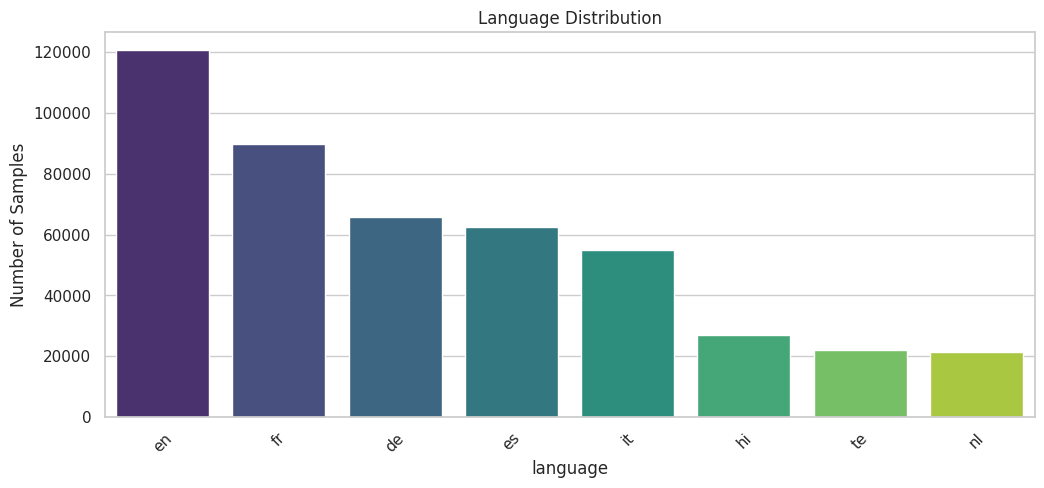

In [ ]:
if "language" in df.columns:
    lang_counts = df["language"].value_counts()
    print("Unique lenguages", len(lang_counts))
    print("\nTop 10 lenguages")
    print(lang_counts.head(10))

    plt.figure(figsize=(12, 5))
    sns.barplot(
        x=lang_counts.head(15).index, y=lang_counts.head(15).values, palette="viridis"
    )
    plt.title("Language Distribution")
    plt.ylabel("Number of Samples")
    plt.xlabel("language")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Colonna 'language' non trovata.")

Total entity founded: 1100556

Top Class PII:
                   count
GIVENNAME         347442
SURNAME           134026
CITY               76605
TELEPHONENUM       73662
TIME               64456
DATE               54438
EMAIL              53994
STREET             49919
BUILDINGNUM        43703
IDCARDNUM          39126
TITLE              37690
AGE                25914
ZIPCODE            18597
PASSPORTNUM        17699
TAXNUM             12402
SEX                11404
CREDITCARDNUMBER   10317
SOCIALNUM          10020
GENDER              9609
DRIVERLICENSENUM    9533


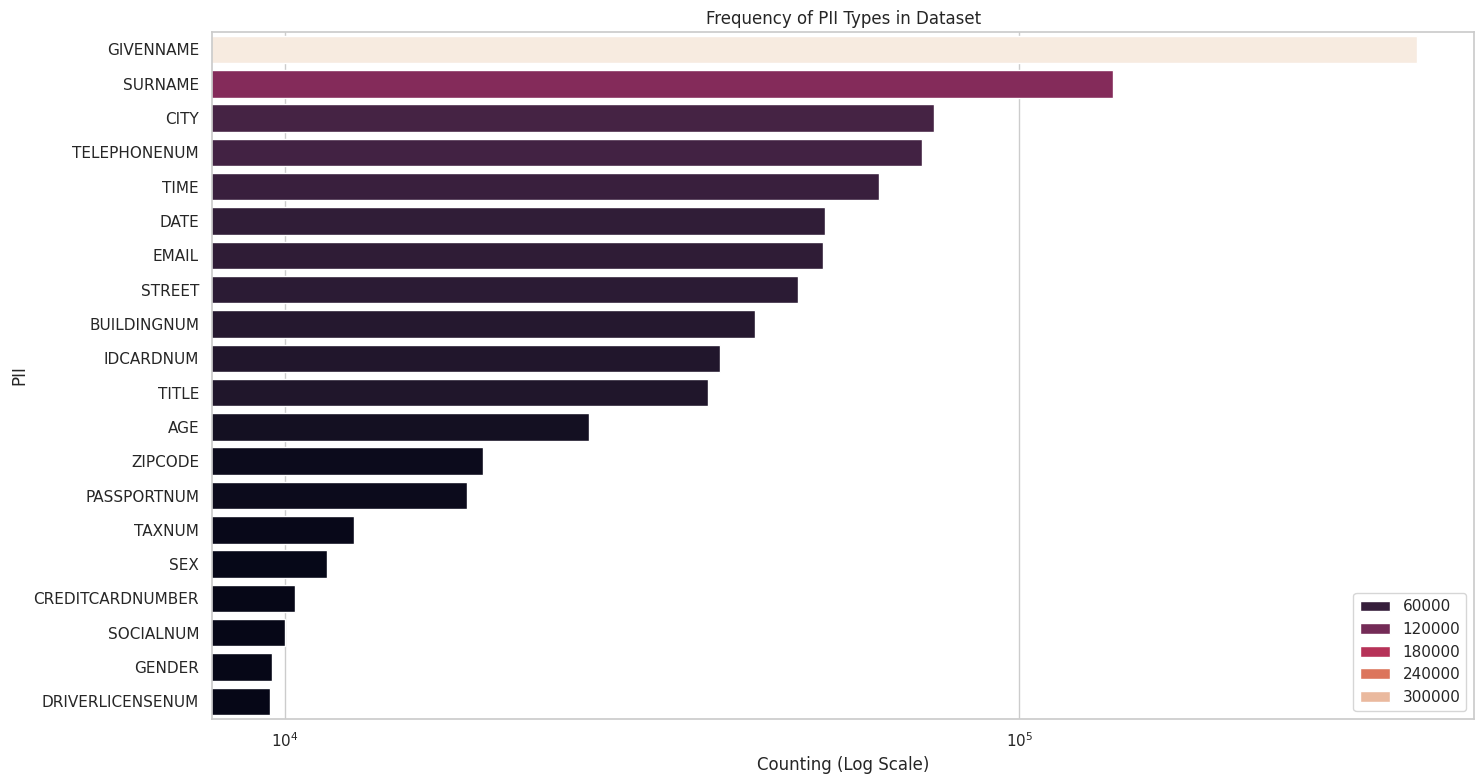

In [48]:
def get_pii_counts(df_column):
    all_labels = []
    for mask_list in df_column:
        for item in mask_list:
            label = None
            if isinstance(item, dict):
                label = item.get("label") or item.get("ner_label")
            elif isinstance(item, (list, tuple)) and len(item) >= 3:
                label = item[2]
            if label:
                all_labels.append(label)
    return Counter(all_labels)


pii_counts = get_pii_counts(df["privacy_mask"])
df_pii = pd.DataFrame.from_dict(
    pii_counts, orient="index", columns=["count"]
).sort_values("count", ascending=False)

print(f"Total entity founded: {df_pii['count'].sum()}")
print("\nTop Class PII:")
print(df_pii[:50])

# Plot
plt.figure(figsize=(15, 8))
sns.barplot(
    x=df_pii["count"].values,
    y=df_pii.index,
    palette="rocket",
    hue=df_pii["count"].values,
    dodge=False,
)
plt.title("Frequency of PII Types in Dataset")
plt.xlabel("Counting (Log Scale)")
plt.xscale("log")
plt.ylabel("PII")
plt.tight_layout()
plt.show()

Lenght stats (approximated tokens):
count    464150.000000
mean         17.378335
std           7.632191
min           0.000000
25%          12.000000
50%          16.000000
75%          22.000000
max         223.000000
Name: text_len_tokens_approx, dtype: float64


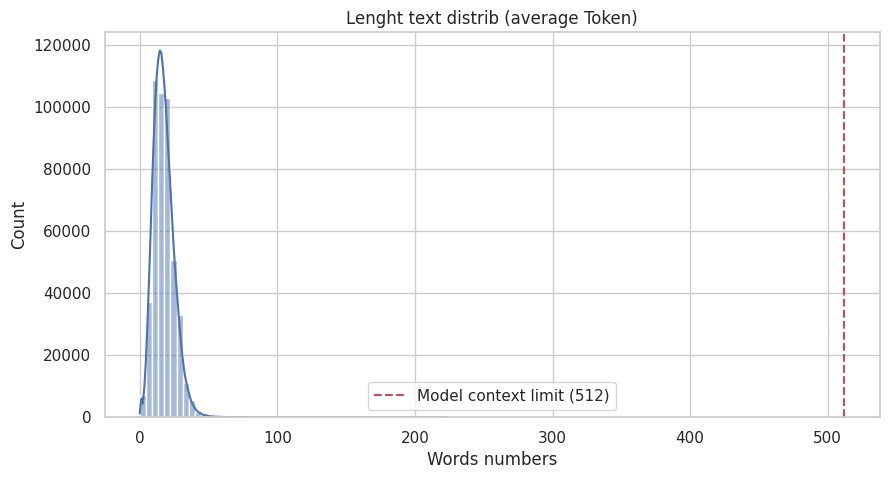

text % > 512 words: 0.00%


In [37]:
df['text_len_chars'] = df['source_text'].str.len()
df['text_len_tokens_approx'] = df['source_text'].str.split().str.len()

print("Lenght stats (approximated tokens):")
print(df['text_len_tokens_approx'].describe())

# Visualizzazione
plt.figure(figsize=(10, 5))
sns.histplot(df['text_len_tokens_approx'], bins=50, kde=True)
plt.axvline(x=512, color='r', linestyle='--', label='Model context limit (512)')
plt.title("Lenght text distrib (average Token)")
plt.xlabel("Words numbers")
plt.legend()
plt.show()

# Percentuale sopra i 512
over_512 = (df['text_len_tokens_approx'] > 512).mean() * 100
print(f"text % > 512 words: {over_512:.2f}%")

In [47]:
def print_annotated_text(text, mask_list):
   sorted_mask = []
   for item in mask_list:
      if isinstance(item, dict):
         sorted_mask.append((item['start'], item['end'], item['label']))
      elif isinstance(item, list):
            sorted_mask.append((item[0], item[1], item[2]))
   
   sorted_mask.sort(key=lambda x: x[0])
   
   output = ""
   prev_end = 0
   for start, end, label in sorted_mask:
      output += text[prev_end:start]
      masked_segment = text[start:end]
      output += f"\033[91m[{masked_segment}]({label})\033[0m"
      prev_end = end
   
   output += text[prev_end:]
   return output

samples = df.sample(3)
for idx, row in samples.iterrows():
   print(f"\nID: {idx} | Language: {row.get('language', 'N/A')}")
   try:
      print(print_annotated_text(row['source_text'], row['privacy_mask']))
   except Exception as e:
      print(f"Visualization error: {e}")
      print(row['source_text'][:200] + "...")
   print("-" * 80)


ID: 430545 | Language: it
La mia storia orale preferita è quella di mio padre, che ha vissuto durante la guerra e ha dovuto nascondersi a [Aegerdi](STREET) [1324](BUILDINGNUM).
--------------------------------------------------------------------------------

ID: 329008 | Language: it
Buona sera, sto cercando di scoprire di più sulla mia eredità etnica. Mia nonna materna è originaria di [Meierskappel](CITY) e mio nonno paterno da [Ermatingen](CITY).
--------------------------------------------------------------------------------

ID: 431573 | Language: fr
Pour participer au projet de compilation d'histoires locales, vous devrez fournir les documents suivants : [B0910077820687](IDCARDNUM), [280122066775897](SOCIALNUM), et [0683435927888](TAXNUM).
--------------------------------------------------------------------------------
